# News Topic Classification System
## Week 1 Submission
### Dataset: AG News Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
train_df = pd.read_csv("dataset/train.csv")

In [5]:
test_df = pd.read_csv("dataset/test.csv")

In [6]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [7]:
print(train_df.columns)

Index(['Class Index', 'Title', 'Description'], dtype='object')


In [8]:
train_df['text'] = train_df['Title'] + " " + train_df['Description']

test_df['text'] = test_df['Title'] + " " + test_df['Description']

In [9]:
train_df.rename(columns={'Class Index': 'label'}, inplace=True)

test_df.rename(columns={'Class Index': 'label'}, inplace=True)

In [10]:
train_df['label'] = train_df['label'] - 1

test_df['label'] = test_df['label'] - 1

In [11]:
label_names = {
    0: 'World',
    1: 'Sports',
    2: 'Business',
    3: 'Sci/Tech'
}

train_df['category'] = train_df['label'].map(label_names)

In [12]:
print(train_df.shape)
print(train_df.columns)

(120000, 5)
Index(['label', 'Title', 'Description', 'text', 'category'], dtype='object')


Dataset contains:
- News text
- Category labels

## Lable Mapping

In [13]:
label_names = {
    0: 'World',
    1: 'Sports',
    2: 'Business',
    3: 'Sci/Tech'
}

train_df['category'] = train_df['label'].map(label_names)

test_df['category'] = test_df['label'].map(label_names)

train_df.head()

,label,Title,Description,text,category
0,2,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,Business
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,2,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new...",Business


### Check Missing Values

In [14]:
train_df.isnull().sum()

label          0
Title          0
Description    0
text           0
category       0
dtype: int64

No missing values found in dataset.

## Class Distribution Graph

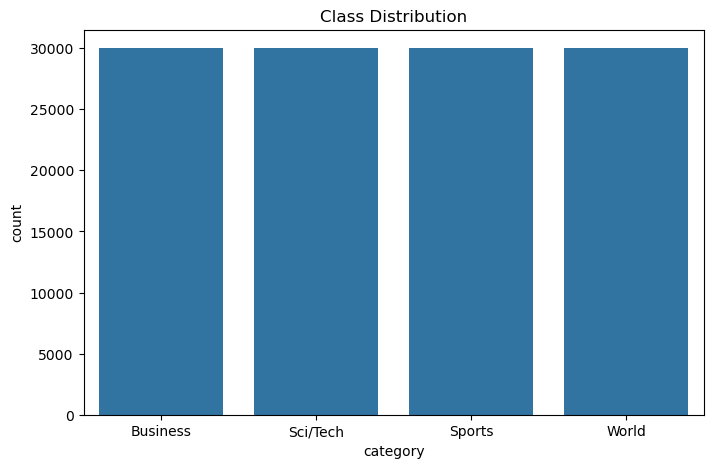

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x='category', data=train_df)

plt.title("Class Distribution")
plt.savefig("results/class_distribution.png")

plt.show()

## Text Length Analysis

In [16]:
train_df['text_length'] = train_df['text'].apply(len)

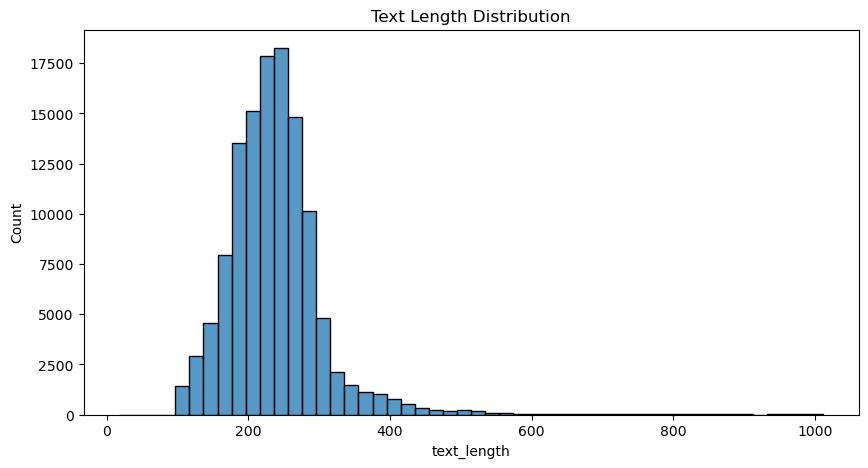

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(train_df['text_length'], bins=50)

plt.title("Text Length Distribution")

plt.savefig("results/text_length_distribution.png")

plt.show()

Most news articles contain medium-length text.

## Text cleaning

In [22]:
import re

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

In [23]:
train_df['clean_text'] = train_df['text'].apply(clean_text)

test_df['clean_text'] = test_df['text'].apply(clean_text)

In [24]:
print(train_df.columns)

Index(['label', 'Title', 'Description', 'text', 'category', 'text_length',
       'clean_text'],
      dtype='object')


Preprocessing steps:
- Lowercasing
- Removing special characters

In [25]:
train_df[['text', 'clean_text']].head()

,text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...",oil prices soar to alltime record posing new m...


## BUILD BASELINE MODEL

### Convert Text into Numbers

In [26]:
vectorizer = CountVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df['clean_text'])

X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']

y_test = test_df['label']

### Train model

In [28]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Prediction

In [29]:
y_pred = model.predict(X_test)

### Accuracy

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8955263157894737


### Classification Report

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1900
           1       0.94      0.96      0.95      1900
           2       0.86      0.86      0.86      1900
           3       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



## Confusion Matrix

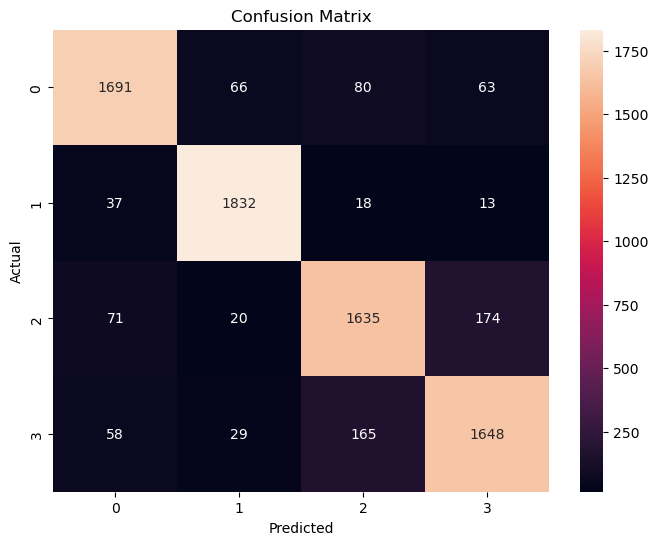

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [33]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result.to_csv("results/baseline_results.csv", index=False)